In [2]:
from sklearn import datasets
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [3]:
digits = datasets.load_digits()
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [5]:
print(digits.images[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


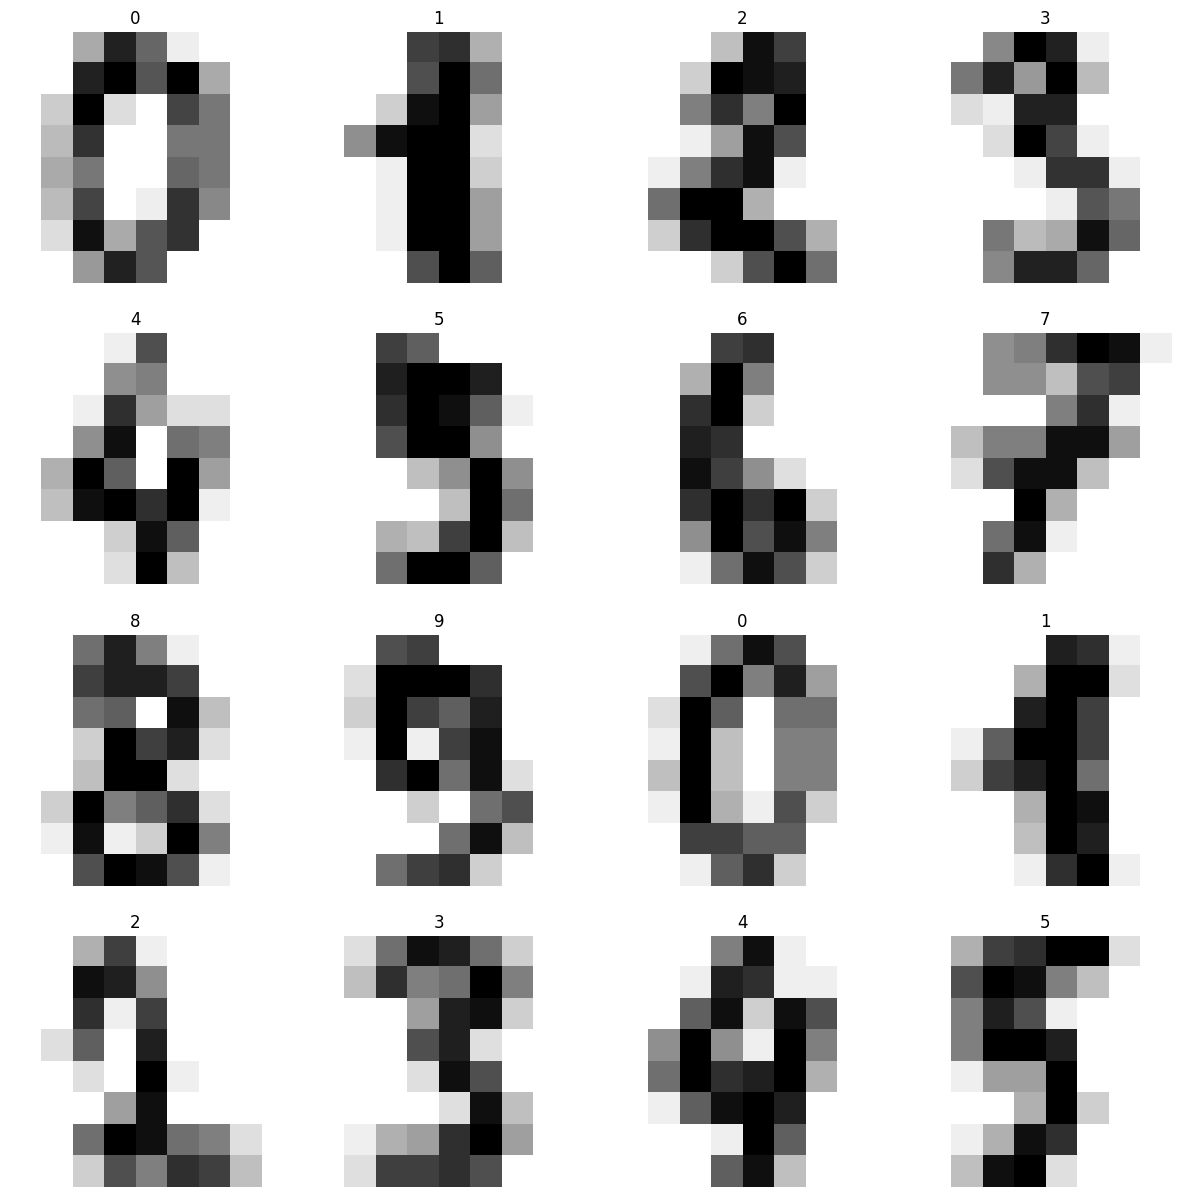

In [6]:
def plot_multi(i):
  nplots = 16
  fig = plt.figure(figsize=(15,15))
  for j in range(nplots):
    plt.subplot(4,4,j+1)
    plt.imshow(digits.images[i+j], cmap='binary')
    plt.title(digits.target[i+j])
    plt.axis('off')
  plt.show()

plot_multi(0)

In [10]:
y = digits.target
x = digits.images.reshape((len(digits.images), -1))
x[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [11]:
x_train = x[:1000]
y_train = y[:1000]

x_test = x[1000:]
y_test = y[1000:]

In [20]:
mlp = MLPClassifier(hidden_layer_sizes=(15,),
                    activation='logistic',
                    alpha=1e-4,
                    solver='sgd',
                    tol=1e-4,
                    random_state=1,
                    learning_rate_init=0.5,
                    verbose=True)

mlp.fit(x_train, y_train)

Iteration 1, loss = 2.20803509
Iteration 2, loss = 1.65096069
Iteration 3, loss = 1.07799980
Iteration 4, loss = 0.80288400
Iteration 5, loss = 0.51022825
Iteration 6, loss = 0.41390890
Iteration 7, loss = 0.32826695
Iteration 8, loss = 0.28436847
Iteration 9, loss = 0.24794435
Iteration 10, loss = 0.21709539
Iteration 11, loss = 0.18691217
Iteration 12, loss = 0.14950499
Iteration 13, loss = 0.16075246
Iteration 14, loss = 0.15845111
Iteration 15, loss = 0.15652201
Iteration 16, loss = 0.14082855
Iteration 17, loss = 0.12346270
Iteration 18, loss = 0.11726601
Iteration 19, loss = 0.11277590
Iteration 20, loss = 0.10826536
Iteration 21, loss = 0.12373375
Iteration 22, loss = 0.10008307
Iteration 23, loss = 0.10815595
Iteration 24, loss = 0.09763551
Iteration 25, loss = 0.07509420
Iteration 26, loss = 0.07215703
Iteration 27, loss = 0.07094570
Iteration 28, loss = 0.06817323
Iteration 29, loss = 0.08841848
Iteration 30, loss = 0.07635416
Iteration 31, loss = 0.11041235
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=(15,),
              learning_rate_init=0.5, random_state=1, solver='sgd',
              verbose=True)

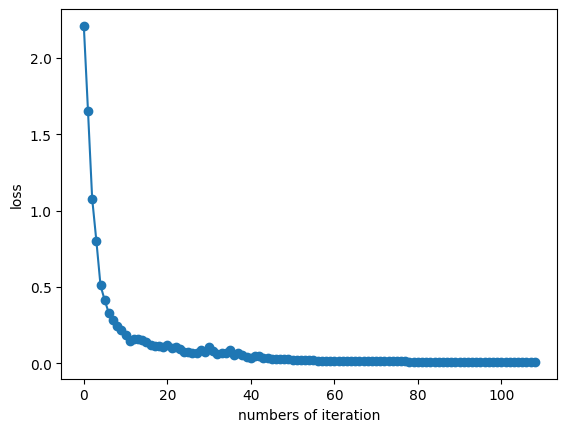

In [21]:
fig, axes = plt.subplots(1,1)
axes.plot(mlp.loss_curve_, 'o-')
axes.set_xlabel('numbers of iteration')
axes.set_ylabel('loss')
plt.show()

In [22]:
predictions = mlp.predict(x_test)
predictions[:50]

array([1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 9, 7, 9, 5,
       4, 4, 9, 0, 8, 9, 8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 9, 0])

In [23]:
y_test[:50]

array([1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 4, 9, 0, 8, 9, 8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 9, 0])

In [24]:
accuracy_score(y_test,predictions)

0.904642409033877